In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive
from tensorflow.keras import models, Input, layers
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [8]:
#On monte le drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'datasets']


In [10]:
print(os.listdir("/content/drive/MyDrive/datasets"))

['dataset_spectrogram.zip']


In [11]:
#on attribut le lien de notre fichier zip
zip_path = "/content/drive/MyDrive/datasets/dataset_spectrogram.zip"
!unzip -oq "$zip_path" -d "/content/dataset"
path_url ="/content/dataset/dataset_spectrogram"
classes = os.listdir(path_url)
print(f"classes detectées {classes}")


classes detectées ['5', 'A', '3', 'hash', '9', '2', 'B', '1', '0', '8', '4', 'D', '7', 'C', 'silence', '6', 'star']


In [12]:
#verification de chaque sous dossier
for c in classes:
    path = f"{path_url}/{c}"
    print(c, ":", len(os.listdir(path)))

5 : 913
A : 905
3 : 900
hash : 911
9 : 910
2 : 893
B : 905
1 : 904
0 : 876
8 : 899
4 : 893
D : 897
7 : 891
C : 903
silence : 811
6 : 895
star : 911


In [13]:


data = []

for label in classes:
    class_path = os.path.join(path_url, label)

    for file in os.listdir(class_path):
        data.append((os.path.join(class_path, file), label))


df = pd.DataFrame(data, columns=["filepath", "label"])

print(f"Total images :{len(df)}")
print(df.head())

Total images :15217
                                           filepath label
0  /content/dataset/dataset_spectrogram/5/5_957.png     5
1  /content/dataset/dataset_spectrogram/5/5_143.png     5
2  /content/dataset/dataset_spectrogram/5/5_963.png     5
3  /content/dataset/dataset_spectrogram/5/5_544.png     5
4  /content/dataset/dataset_spectrogram/5/5_397.png     5


In [14]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 10651 | Val: 2283 | Test: 2283


In [15]:

train_df["label"].value_counts(normalize=True)
val_df["label"].value_counts(normalize=True)
test_df["label"].value_counts(normalize=True)

,proportion
label,
5,0.060009
star,0.060009
9,0.060009
A,0.059571
hash,0.059571
B,0.059571
6,0.059133
3,0.059133
C,0.059133


In [16]:
# Forcer en string (sécurité)
train_df["label"] = train_df["label"].astype(str)
val_df["label"]   = val_df["label"].astype(str)
test_df["label"]  = test_df["label"].astype(str)

In [17]:
# verification NaN dans les images (détecte les spectrogrammes corrompus)

def check_nan_in_images(df_subset, n_check=700, label="set"):
    bad = 0
    for _, row in df_subset.sample(min(n_check, len(df_subset)),
                                   random_state=0).iterrows():
        img = cv2.imread(row["filepath"], cv2.IMREAD_GRAYSCALE)
        if img is None or np.isnan(img).any() or np.isinf(img).any():
            bad += 1
    print(f"[{label}] Images corrompues sur {n_check} échantillons : {bad}")

check_nan_in_images(train_df, label="train")
check_nan_in_images(val_df,   label="val")


[train] Images corrompues sur 700 échantillons : 0
[val] Images corrompues sur 700 échantillons : 0


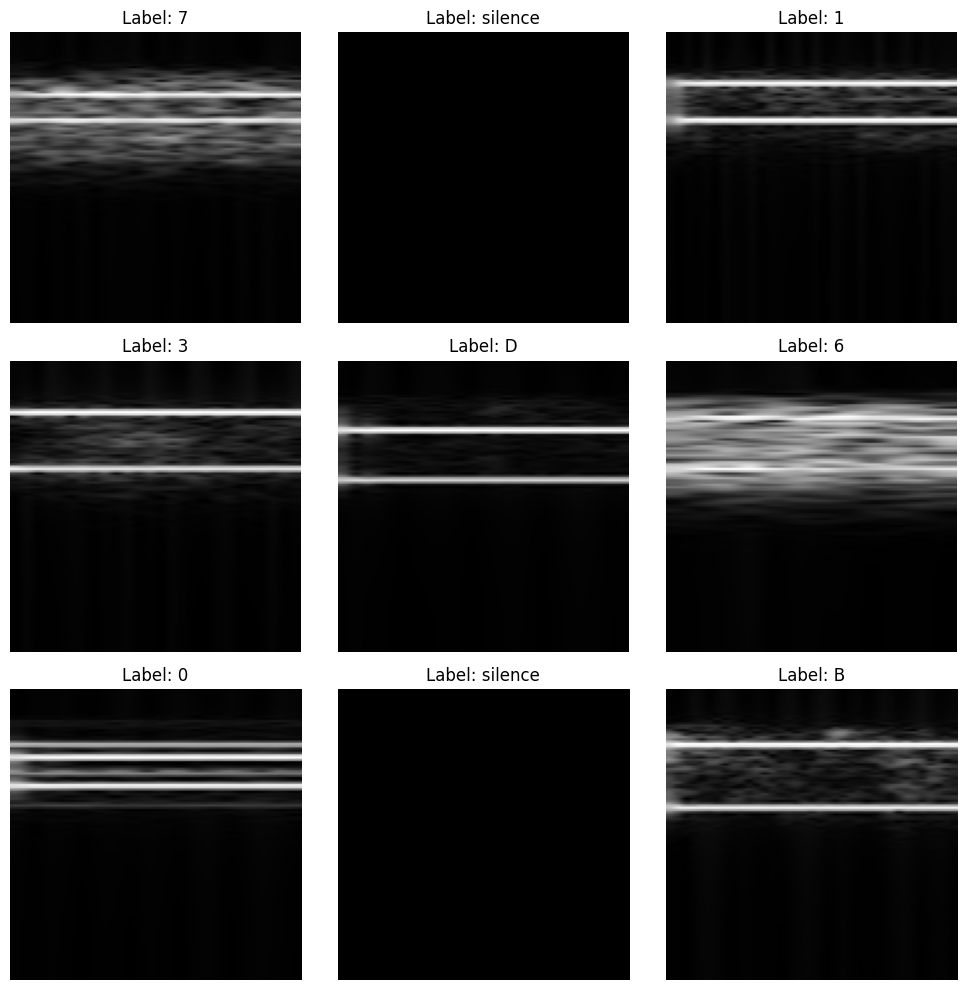

In [18]:
# afficher quelques images
sample = train_df.sample(9, random_state=42)

plt.figure(figsize=(10,10))

for i, (idx, row) in enumerate(sample.iterrows()):
    img = cv2.imread(row["filepath"], cv2.IMREAD_GRAYSCALE)

    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {row['label']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:

# Générateurs d'images
# color_mode='grayscale' (images MATLAB = 1 canal)

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Légère augmentation sur le train (rotation, zoom) — optionnel
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',      # entiers 0..N-1 auto-générés
    color_mode='grayscale',   #  1 canal au lieu de 3
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    color_mode='grayscale',
    shuffle=False
)

test_generator = val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    color_mode='grayscale',
    shuffle=False
)

Found 10651 validated image filenames belonging to 17 classes.
Found 2283 validated image filenames belonging to 17 classes.
Found 2283 validated image filenames belonging to 17 classes.


In [20]:
# Récupérer le mapping classes → indices pour les rapports
class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
num_classes = len(class_indices)
print(f"\nNombre de classes : {num_classes}")
print("Mapping classes :", class_indices)


Nombre de classes : 17
Mapping classes : {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'A': 10, 'B': 11, 'C': 12, 'D': 13, 'hash': 14, 'silence': 15, 'star': 16}


In [21]:
# construction du modèle
#Input (128,128,1) — grayscale
def build_model(num_classes):
    model = models.Sequential([

        Input(shape=(128, 128, 1)),   # 1 canal

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation='softmax')
    ])

    # clipnorm pour éviter explosion des gradients
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


cnn_model = build_model(num_classes)
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,589,713 (17.51 MB)

 Trainable params: 4,588,241 (17.50 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [22]:

# callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Réduit le LR si plateau → stabilise l'entraînement
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [early_stop, checkpoint, reduce_lr]

In [23]:

# 9. ENTRAÎNEMENT
print(f"\nTrain samples    : {train_generator.samples}")
print(f"Batch size       : {train_generator.batch_size}")
print(f"Steps per epoch  : {len(train_generator)}")
print(f"Val samples      : {val_generator.samples}")
print(f"Val steps        : {len(val_generator)}\n")

history = cnn_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_list
)


Train samples    : 10651
Batch size       : 32
Steps per epoch  : 333
Val samples      : 2283
Val steps        : 72

Epoch 1/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6546 - loss: 1.2004
Epoch 1: val_loss improved from None to 54.62440, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 55s 126ms/step - accuracy: 0.8169 - loss: 0.6768 - val_accuracy: 0.0578 - val_loss: 54.6244 - learning_rate: 0.0010
Epoch 2/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9397 - loss: 0.2890
Epoch 2: val_loss improved from 54.62440 to 48.82357, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 31s 92ms/step - accuracy: 0.9466 - loss: 0.2663 - val_accuracy: 0.0596 - val_loss: 48.8236 - learning_rate: 0.0010
Epoch 3/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9648 - loss: 0.2067
Epoch 3: val_loss improved from 48.82357 to 17.57988, sav

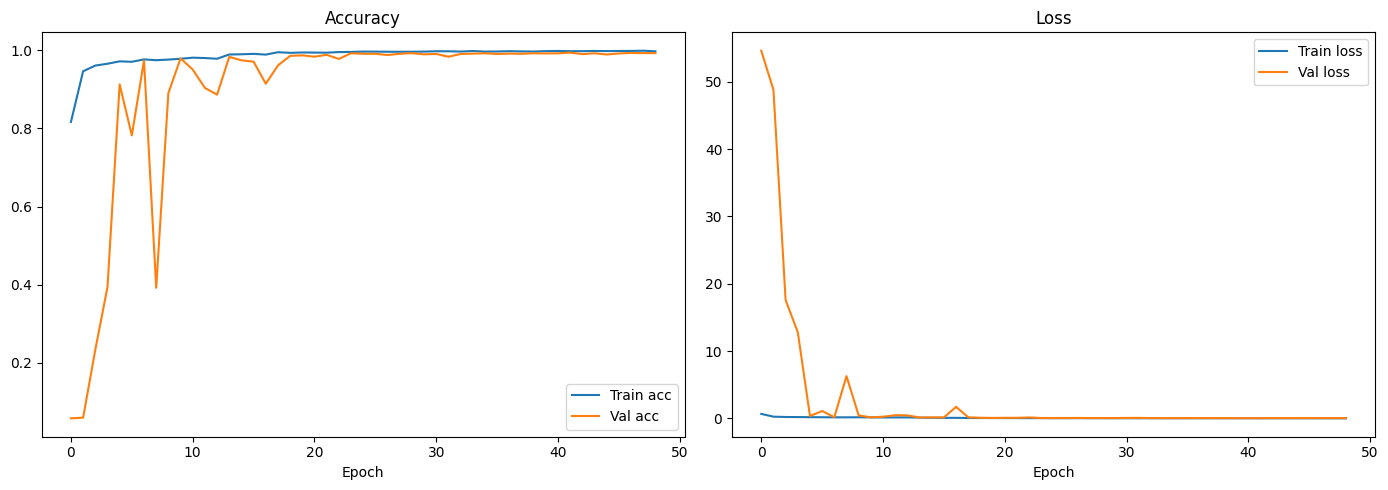

In [24]:

# courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train acc')
axes[0].plot(history.history['val_accuracy'], label='Val acc')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

In [25]:

# evaluation sur le jeu de test
best_model = tf.keras.models.load_model("best_model.keras")

test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest accuracy : {test_acc:.4f}  |  Test loss : {test_loss:.4f}")

# Prédictions
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes

target_names = [index_to_class[i] for i in range(num_classes)]
print("\n Rapport de classification ")
print(classification_report(y_true, y_pred, target_names=target_names))

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9908 - loss: 0.0703

Test accuracy : 0.9908  |  Test loss : 0.0703
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step

── Rapport de classification ──
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       131
           1       0.99      1.00      0.99       135
           2       0.99      1.00      1.00       134
           3       0.99      0.99      0.99       135
           4       0.99      0.99      0.99       134
           5       0.99      1.00      1.00       137
           6       0.99      0.99      0.99       135
           7       1.00      0.99      1.00       134
           8       1.00      0.97      0.98       135
           9       1.00      1.00      1.00       137
           A       0.97      1.00      0.99       136
           B       0.97      0.96      0.96       136
           C       0.99      0.99      0.99       135
           D       1.00      0.99      1.00      

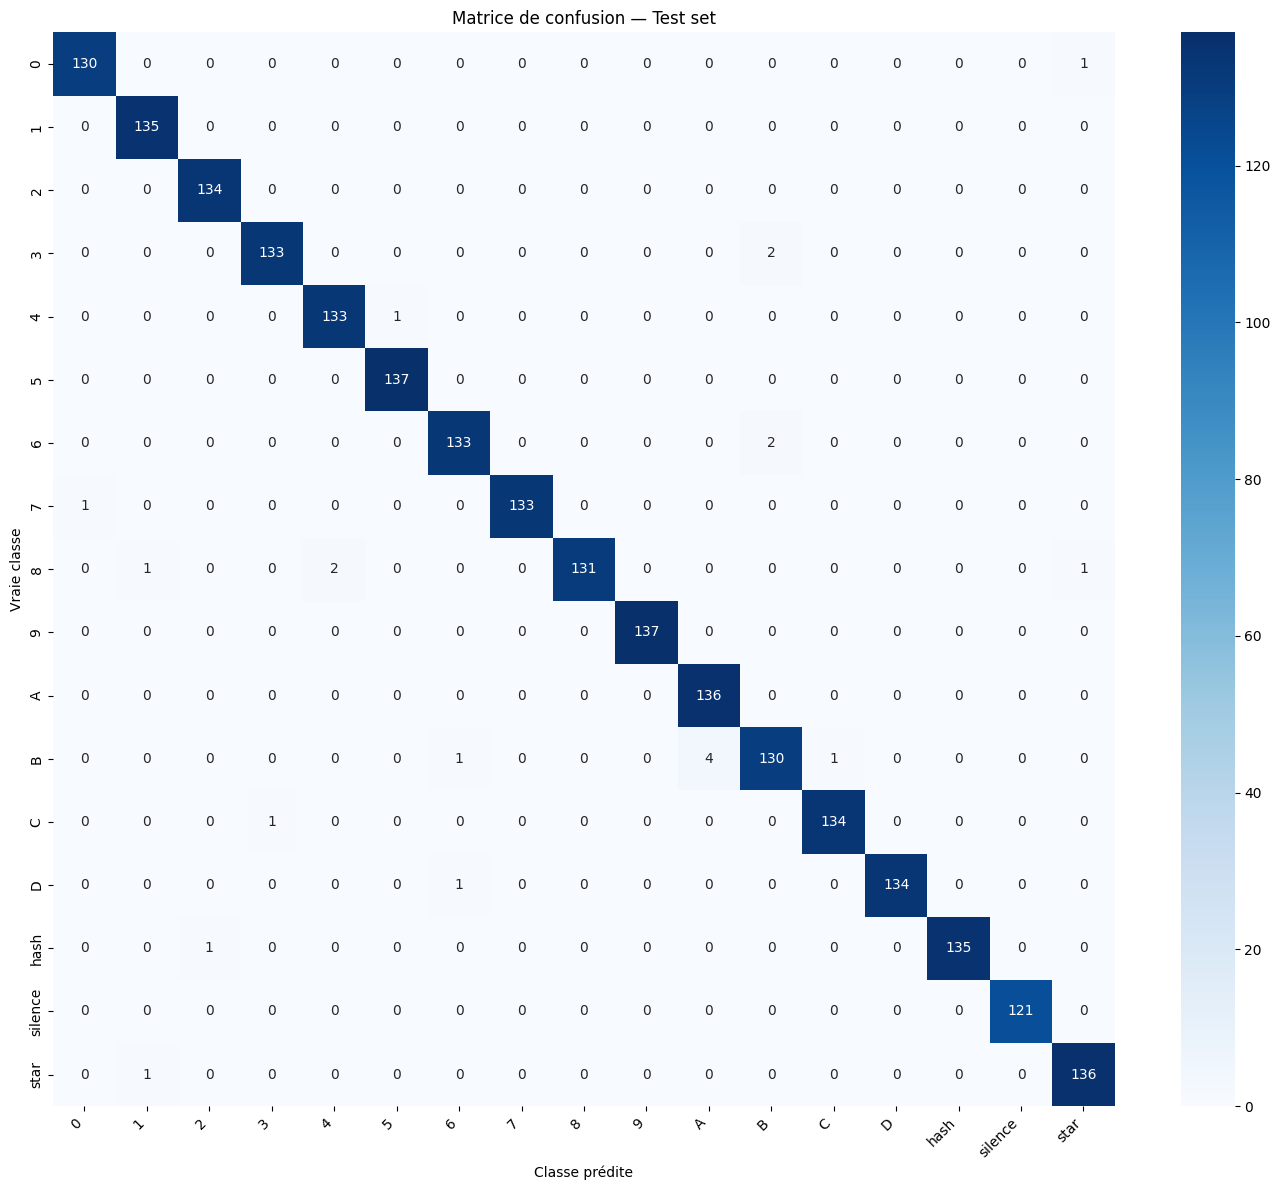

In [27]:

# matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Matrice de confusion — Test set")
plt.ylabel("Vraie classe")
plt.xlabel("Classe prédite")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()